# Phase 4B — Adaptive ML Signal Models (F7)

**Purpose:** This notebook is *evidentiary*, not exploratory. It shows what F7 — the EURAFRIC
functional diagram's "Adaptive ML Models (RF/XGBoost/LSTM), HMM regime-conditional return
prediction, signals for portfolio optimization" — actually does on live data, and reports the
honest result against the Phase 4 hurdle every Phase 4B strategy must beat net of costs,
out-of-sample.

**F7 is not Phase 4 (F4).** F4 — already built, `notebooks/phase4_regime_covariance.ipynb` —
detects a market regime and hard-switches between two existing Markowitz optimizers. It never
predicts a return. F7 is the missing piece: a supervised model that learns to forecast each
asset's next-period return, conditioned on the HMM regime posterior as one input feature, and
feeds that prediction as `mu` into the *same* Sharpe-maximization objective every prior Phase 4
covariance rung already reused — zero new optimizer code.

| Problem | What this notebook shows |
|---------|--------------------------|
| **P1** | Predicted `mu` replaces the noisy sample mean already fed into `MaxSharpe`'s objective — does a learned estimate actually beat the naive one net of costs? |
| **P2** | The pooled model conditions on regime and rolling per-asset features rather than assuming a static return distribution — §3 checks whether the regime feature is actually used, not just present |
| **P3** | The pooled cross-sectional panel (asset identity as a feature, not per-asset models) lets every asset's rows inform the same fit — the practical answer to `full_2021`'s thin ~1,255-row history |
| **P4** | Every strategy compared here runs through the *same* leakage-free engine Phase 2 built; `tests/test_phase4b_integration.py` proves **label construction** (not just feature slicing) doesn't leak, end-to-end, for the real strategies — this notebook does not re-litigate that proof, it reports results from it |

**No-lookahead guarantee — proven elsewhere, not here:** `tests/test_phase4b_integration.py`
already proves `RandomForestSignalStrategy`/`XGBoostSignalStrategy` cannot see a future realized
return, using the real strategies (not a toy probe) — the labels-specific version of the proof
`test_phase4_integration.py` already ran for Phase 4's features. This notebook trusts that proof
and focuses on what the models *found*, not on re-deriving that they're honest.

**Data caveats carried forward from Phase 1–4 (see `CLAUDE.md` §8.4 for the full list):**
- `full_2021` (9 assets) starts mid-2021 (BVC free-source rolling window); `etf_2017` (5 ETFs)
  covers 2017→today.
- `EEM` is stationarity-AMBIGUOUS — unchanged risk, inherited from Phase 1.
- BVC returns are MAD-denominated, ETFs USD — an unhedged USD/MAD exposure is embedded and not
  "fixed" here (out of scope).
- **LSTM (the third F7 model family) was built and passed its own isolated 10-test suite, then
  dropped from this comparison** after `torch` and `xgboost` loaded together in the same process
  caused a hard segfault — a native/OpenMP library conflict on this development machine, not a
  defect in either library. Deferred to a run on more capable/isolated hardware, not abandoned;
  no LSTM code remains on this branch. See `CLAUDE.md`'s Phase 4B notes for the full story.

> ## ✅ Re-executed 2026-07-29 on dividend-corrected data
>
> This notebook was first run before two data corrections. It has since been **re-executed end to
> end against the corrected 2026-07-24 Gold snapshot**, so every figure below is current — not a
> historical record.
>
> **1. BVC dividend bias.** The pipeline mixed two return definitions: ETFs arrived
> dividend-adjusted (`yfinance auto_adjust=True`, total return) while BVC arrived price-only
> (`BVCscrap feature="Value"`), discarding 3.0–4.3%/yr of real dividends. It did not cancel across
> strategies — `equal_weight` is forced to hold the understated assets while the optimizers can
> underweight them, so it **inflated every optimizer's measured edge**. Fixed in `src/dividends.py`
> + `clean.compute_log_returns(prices, dividends=...)`, which applies each payment on its ex-date.
>
> **2. Deep ETF window.** `etf_2017` now starts **2004-11-18** (GLD's inception), not 2017-01-01.
> The old start was a project decision, not a data limit. This cut bootstrap CI width by 38% and
> brought the 2008 crisis into the sample.
>
> | | Original run | **This run (current)** |
> |---|---:|---:|
> | `etf_2017` hurdle | `max_sharpe` 0.936 | **`min_variance` 0.9525** |
> | `full_2021` hurdle | `regime_conditional` 1.122 | **`regime_conditional` 1.2363** |
> | `rf_signal` (`etf_2017`) | 0.727 | **0.904** |
> | `rf_signal` (`full_2021`) | 1.062 | **1.123** |
> | `xgb_signal` (`full_2021`) | 0.743 | **0.873** |
>
> **The negative result survives — and the margin WIDENED.** On `full_2021` the gap from
> `rf_signal` to the hurdle grew from −0.060 to **−0.113**, because the correction lifted the
> regime baseline (+0.115) more than it lifted the signal (+0.061). `rf_signal` improved
> substantially on `etf_2017` (0.727 → 0.904) purely from the deep window's extra training
> history, and still does not clear the classical hurdle — the same "more data makes the model
> better, not the portfolio" pattern the deep-Morocco experiment found.
>
> One claim in this notebook is retracted outright — see the inline **[RETRACTED]** note below.
>
> Full analysis: [`docs/DIVIDEND_BIAS.md`](../docs/DIVIDEND_BIAS.md) ·
> [`docs/ETF_DEEP_HISTORY_EXPERIMENT.md`](../docs/ETF_DEEP_HISTORY_EXPERIMENT.md)


## 1. Setup — universes, Phase 3 features, and the Phase 4 hurdle (P4)

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NB_CWD = Path.cwd()
SRC = (NB_CWD.parent / "src") if (NB_CWD.parent / "src").exists() else (NB_CWD / "src")
sys.path.insert(0, str(SRC))

from backtest import build_cost_vector, run_backtest
from metrics import annualized_sharpe, max_drawdown, summarize
from run_phase4b import PHASE4B_STRATEGY_NAMES, ROOT, build_strategies
from run_phase4 import load_features, load_universe
from utils import load_params

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

P = load_params()
BP = P["backtest"]
SP = P["ml_signals"]

UNIVERSES = {name: load_universe(path) for name, path in BP["universes"].items()}
FEATURES = {name: load_features(P["ml_features"]["outputs"][name]) for name in BP["universes"]}
HURDLE = json.loads((ROOT / "data" / "gold" / "phase4_results.json").read_text())

for name, df in UNIVERSES.items():
    print(f"{name}: {df.shape[0]} days x {df.shape[1]} assets   "
          f"{df.index.min().date()} -> {df.index.max().date()}   "
          f"Phase 4 hurdle: {HURDLE[name]['strategy']} @ {HURDLE[name]['sharpe_net']:.4f}")

etf_2017: 5656 days x 5 assets   2004-11-19 -> 2026-07-24   Phase 4 hurdle: min_variance @ 0.9525
full_2021: 1321 days x 9 assets   2021-07-02 -> 2026-07-24   Phase 4 hurdle: regime_conditional @ 1.2363


## 2. Run the full comparison — 7 existing strategies + 2 new F7 strategies (P1–P4)

One pass, both universes: the 4 Phase 2 baselines and 3 Phase 4 strategies (`EqualWeight`,
`MinVariance`, `MinVarianceLW`, `MaxSharpe`, `MinVarianceEWMA`, `DCCGarchStrategy`,
`RegimeConditionalStrategy`) alongside the 2 new F7 strategies (`RandomForestSignalStrategy`,
`XGBoostSignalStrategy`) — the exact same `build_strategies()` `src/run_phase4b.py` uses, so this
notebook's numbers are the live, reproducible ones, not a hand-copied table. The DSR
`trial_sharpes` pool is honest across all 9 (the N-honesty rule from `run_phase4b.py`'s
docstring).

**Runtime note:** dominated by `DCCGarchStrategy`'s per-asset GARCH refits and the two pooled-panel
model refits at every rebalance — expect several minutes, most of it in this cell.

In [2]:
STRATEGIES_BY_UNIVERSE = {name: build_strategies(P) for name in UNIVERSES}

RESULTS = {}
for uni_name, returns in UNIVERSES.items():
    costs = build_cost_vector(
        returns.columns,
        etf_cost_bps=BP["costs_bps"]["etf"],
        bvc_cost_bps=BP["costs_bps"]["bvc"],
    )
    RESULTS[uni_name] = [
        run_backtest(
            returns, s,
            rebalance_freq=BP["rebalance_freq"],
            min_train_days=BP["min_train_days"],
            cost_bps=costs,
            extras={"features": FEATURES[uni_name]},
            universe_name=uni_name,
            max_weight=BP["max_weight"],
        )
        for s in STRATEGIES_BY_UNIVERSE[uni_name]
    ]
    print(f"{uni_name}: {len(RESULTS[uni_name])} strategies backtested "
          f"({', '.join(r.strategy_name for r in RESULTS[uni_name])}).")

2026-07-30 10:56:34,174 | INFO | backtest | Backtest equal_weight/etf_2017: 248 rebalances, OOS 2005-12-01 → 2026-07-24 (5387 days), avg turnover 0.032


2026-07-30 10:56:34,897 | INFO | backtest | Backtest min_variance/etf_2017: 248 rebalances, OOS 2005-12-01 → 2026-07-24 (5387 days), avg turnover 0.032


2026-07-30 10:56:36,255 | INFO | backtest | Backtest min_variance_lw/etf_2017: 248 rebalances, OOS 2005-12-01 → 2026-07-24 (5387 days), avg turnover 0.032


2026-07-30 10:56:36,821 | INFO | backtest | Backtest max_sharpe/etf_2017: 248 rebalances, OOS 2005-12-01 → 2026-07-24 (5387 days), avg turnover 0.038


2026-07-30 10:56:39,639 | INFO | backtest | Backtest min_variance_ewma/etf_2017: 248 rebalances, OOS 2005-12-01 → 2026-07-24 (5387 days), avg turnover 0.061


...

2026-07-30 11:46:34,494 | WARNING | regime | regime: only 198 usable rows (< min_regime_train_days=252) — returning neutral 50/50 posterior.


2026-07-30 11:46:34,688 | WARNING | regime | regime: only 219 usable rows (< min_regime_train_days=252) — returning neutral 50/50 posterior.


2026-07-30 11:46:34,878 | WARNING | regime | regime: only 242 usable rows (< min_regime_train_days=252) — returning neutral 50/50 posterior.


2026-07-30 11:46:54,872 | INFO | backtest | Backtest xgb_signal/full_2021: 49 rebalances, OOS 2022-07-01 → 2026-07-24 (1061 days), avg turnover 1.061


full_2021: 9 strategies backtested (equal_weight, min_variance, min_variance_lw, max_sharpe, min_variance_ewma, dcc_garch, regime_conditional, rf_signal, xgb_signal).


## 3. Does the model actually use the regime feature? (P2)

The open question flagged in `CLAUDE.md`'s Phase 4B notes: is `REGIME_BULL_PROB` pulling its
weight in the pooled model, or is "regime-conditional" a claim the model ignores in practice?
Fitted directly here (mirroring what `ml_signals.fit_predict_expected_returns` does internally)
so `feature_importances_` can be inspected — the strategies themselves don't expose the fitted
model, by design (`Strategy.fit()`'s contract returns weights only).

In [3]:
from ml_signals import (
    attach_regime_feature,
    build_asset_features,
    build_supervised_dataset,
    melt_to_panel,
)

FEATURE_IMPORTANCE = {}
for uni_name, returns in UNIVERSES.items():
    wide = build_asset_features(
        returns,
        short_window=SP["short_window"],
        long_window=SP["long_window"],
        momentum_windows=SP["momentum_windows"],
    )
    panel = melt_to_panel(wide, list(returns.columns))
    panel = attach_regime_feature(
        panel, FEATURES[uni_name],
        n_states=P["regime"]["n_states"],
        n_restarts=P["regime"]["n_restarts"],
        random_state_base=P["regime"]["random_state_base"],
        covariance_type=P["regime"]["covariance_type"],
        min_regime_train_days=P["regime"]["min_regime_train_days"],
    )
    X, y, _ = build_supervised_dataset(panel, returns)

    from sklearn.ensemble import RandomForestRegressor
    from xgboost import XGBRegressor

    rf = RandomForestRegressor(**SP["random_forest"]).fit(X.to_numpy(), y.to_numpy())
    xgb = XGBRegressor(**SP["xgboost"]).fit(X.to_numpy(), y.to_numpy())

    imp = pd.DataFrame({
        "rf_importance": rf.feature_importances_,
        "xgb_importance": xgb.feature_importances_,
    }, index=X.columns).sort_values("rf_importance", ascending=False)
    FEATURE_IMPORTANCE[uni_name] = imp

    regime_rank_rf = list(imp.index).index("REGIME_BULL_PROB") + 1
    regime_rank_xgb = list(imp["xgb_importance"].sort_values(ascending=False).index).index("REGIME_BULL_PROB") + 1
    n_features = len(imp)
    print(f"=== {uni_name} ({n_features} features, {len(X)} pooled training rows) ===")
    print(f"  REGIME_BULL_PROB rank: RF {regime_rank_rf}/{n_features}, XGB {regime_rank_xgb}/{n_features}")
    print(imp.head(8))
    print()

=== etf_2017 (7 features, 27965 pooled training rows) ===
  REGIME_BULL_PROB rank: RF 7/7, XGB 1/7
                  rf_importance  xgb_importance
RET_21D                  0.2632          0.1230
RET_5D                   0.2256          0.1666
PRICE_REL_MA_63D         0.2146          0.1062
VOL_21D                  0.1883          0.1360
VOL_63D                  0.0669          0.1666
RET_63D                  0.0404          0.1224
REGIME_BULL_PROB         0.0009          0.1793



=== full_2021 (7 features, 11322 pooled training rows) ===
  REGIME_BULL_PROB rank: RF 7/7, XGB 3/7
                  rf_importance  xgb_importance
PRICE_REL_MA_63D         0.3759          0.2094
RET_5D                   0.1786          0.1062
RET_21D                  0.1647          0.1253
RET_63D                  0.1224          0.1491
VOL_21D                  0.0731          0.1317
VOL_63D                  0.0538          0.1391
REGIME_BULL_PROB         0.0316          0.1392



**Reading the ranks above:** if `REGIME_BULL_PROB` sits near the top, the "regime-conditional"
claim is earning its name. If it sits near the bottom, the pooled model is effectively ignoring
regime and leaning entirely on per-asset trailing return/volatility/price-relative-to-MA
features — worth knowing before writing "regime-conditional" into any deliverable as a claimed
advantage over a model that simply omitted the feature.

## 4. `rf_signal` vs `xgb_signal` — the turnover red flag (P1, P4)

`CLAUDE.md`'s Phase 4B result flagged `xgb_signal`'s very high turnover on `full_2021` (>1.0,
essentially a full portfolio turnover every rebalance) as the standout finding — a possible sign
the predicted-return signal is too noisy/unstable across rebalances to trust net of cost. Checked
directly here against both universes and both new strategies.

In [4]:
rows = []
for uni_name, results in RESULTS.items():
    for r in results:
        if r.strategy_name in PHASE4B_STRATEGY_NAMES:
            rows.append({
                "universe": uni_name,
                "strategy": r.strategy_name,
                "avg_turnover": float(r.turnover.mean()),
                "max_turnover": float(r.turnover.max()),
                "gross_sharpe": annualized_sharpe(r.gross_returns),
                "net_sharpe": annualized_sharpe(r.net_returns),
                "cost_drag": float((r.gross_returns - r.net_returns).sum()),
            })
turnover_table = pd.DataFrame(rows).set_index(["universe", "strategy"])
turnover_table

avg_turnover  max_turnover  gross_sharpe  net_sharpe  \
universe  strategy                                                           
etf_2017  rf_signal         0.1266        1.0000        0.9164      0.9040   
          xgb_signal        0.3800        1.0000        0.7269      0.6941   
full_2021 rf_signal         0.7788        1.5484        1.2742      1.1230   
          xgb_signal        1.0612        2.0000        1.0719      0.8735   

                      cost_drag  
universe  strategy               
etf_2017  rf_signal      0.0314  
          xgb_signal     0.0942  
full_2021 rf_signal      0.0718  
          xgb_signal     0.0973

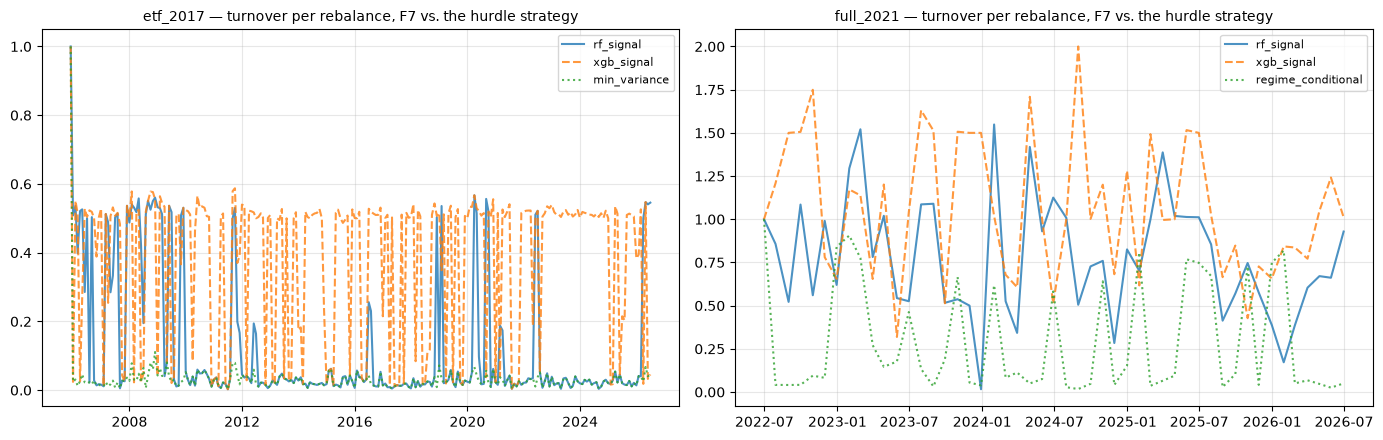

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, uni_name in zip(axes, UNIVERSES):
    by_name = {r.strategy_name: r for r in RESULTS[uni_name]}
    for name, style in [("rf_signal", "-"), ("xgb_signal", "--"), (HURDLE[uni_name]["strategy"], ":")]:
        r = by_name[name]
        ax.plot(r.turnover.index, r.turnover.values, style, label=name, alpha=0.8)
    ax.set_title(f"{uni_name} — turnover per rebalance, F7 vs. the hurdle strategy", fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Full scoreboard — every Phase 4B strategy vs. the Phase 4 hurdle (P1, P4)

Same `metrics.summarize()` panel Phase 2/4 used, now over all 9 strategies with a shared DSR
trial pool per universe (the N-honesty rule from `run_phase4b.py`'s docstring) — the exact
numbers `data/gold/phase4b_results.json` was built from.

In [6]:
panels = []
for uni_name, results in RESULTS.items():
    trial_sharpes = [
        float(r.net_returns.mean() / r.net_returns.std()) if r.net_returns.std() > 0 else 0.0
        for r in results
    ]
    ew_net = next(r for r in results if r.strategy_name == "equal_weight").net_returns
    for r in results:
        panel = summarize(
            r.net_returns, r.gross_returns, r.turnover,
            benchmark_net=ew_net if r.strategy_name != "equal_weight" else None,
            trial_sharpes=trial_sharpes, risk_free_annual=BP["risk_free_annual"],
        )
        panel["universe"], panel["strategy"] = uni_name, r.strategy_name
        panel["is_phase4b"] = r.strategy_name in PHASE4B_STRATEGY_NAMES
        panels.append(panel)

metrics_table = pd.DataFrame(panels).set_index(["universe", "strategy"])
metrics_table[["ann_return_net", "sharpe_net", "max_drawdown_net", "avg_turnover", "dsr_net", "n_trials", "is_phase4b"]]

ann_return_net  sharpe_net  max_drawdown_net  \
universe  strategy                                                           
etf_2017  equal_weight                0.0962      0.7694           -0.3621   
          min_variance                0.1028      0.9525           -0.2689   
          min_variance_lw             0.1028      0.9525           -0.2689   
          max_sharpe                  0.1079      0.9120           -0.3280   
          min_variance_ewma           0.0933      0.8942           -0.2689   
          dcc_garch                   0.0926      0.8880           -0.2692   
          regime_conditional          0.1038      0.9371           -0.2689   
          rf_signal                   0.1050      0.9040           -0.3223   
          xgb_signal                  0.0877      0.6941           -0.4095   
full_2021 equal_weight                0.1158      1.1597           -0.1359   
          min_variance                0.0992      1.0751           -0.1278   
          min_variance_lw             0.0991      1.0743           -0.1280   
          max_sharpe                  0.1320      1.1644           -0.1320   
          min_variance_ewma           0.1072      1.1926           -0.1303   
          dcc_garch                   0.1079      1.2281           -0.1289   
          regime_conditional          0.1218      1.2363           -0.1414   
          rf_signal                   0.1278      1.1230           -0.1408   
          xgb_signal                  0.1004      0.8735           -0.1451   

                              avg_turnover  dsr_net  n_trials  is_phase4b  
universe  strategy                                                         
etf_2017  equal_weight              0.0322   0.9983    9.0000       False  
          min_variance              0.0318   0.9999    9.0000       False  
          min_variance_lw           0.0318   0.9999    9.0000       False  
          max_sharpe                0.0380   0.9998    9.0000       False  
          min_variance_ewma         0.0613   0.9998    9.0000       False  
          dcc_garch                 0.1298   0.9997    9.0000       False  
          regime_conditional        0.0561   0.9999    9.0000       False  
          rf_signal                 0.1266   0.9998    9.0000        True  
          xgb_signal                0.3800   0.9954    9.0000        True  
full_2021 equal_weight              0.0537   0.9776    9.0000       False  
          min_variance              0.0734   0.9665    9.0000       False  
          min_variance_lw           0.0716   0.9664    9.0000       False  
          max_sharpe                0.1445   0.9778    9.0000       False  
          min_variance_ewma         0.1788   0.9812    9.0000       False  
          dcc_garch                 0.3633   0.9852    9.0000       False  
          regime_conditional        0.2926   0.9847    9.0000       False  
          rf_signal                 0.7788   0.9742    9.0000        True  
          xgb_signal                1.0612   0.9253    9.0000        True

In [7]:
PHASE4B_RESULTS = json.loads((ROOT / "data" / "gold" / "phase4b_results.json").read_text())
for uni_name, entry in PHASE4B_RESULTS.items():
    verdict = "BEATS" if entry["beats_phase4_hurdle"] else "does not beat"
    print(f"{uni_name}: best is {entry['strategy']} (net Sharpe {entry['sharpe_net']:.4f}) "
          f"-- {verdict} the Phase 4 hurdle ({HURDLE[uni_name]['strategy']} @ {HURDLE[uni_name]['sharpe_net']:.4f})")
    for name in ("rf_signal", "xgb_signal"):
        r = next(res for res in RESULTS[uni_name] if res.strategy_name == name)
        print(f"    {name}: net Sharpe {annualized_sharpe(r.net_returns):.4f}, "
              f"avg turnover {float(r.turnover.mean()):.3f}")

etf_2017: best is min_variance (net Sharpe 0.9525) -- does not beat the Phase 4 hurdle (min_variance @ 0.9525)
    rf_signal: net Sharpe 0.9040, avg turnover 0.127
    xgb_signal: net Sharpe 0.6941, avg turnover 0.380
full_2021: best is regime_conditional (net Sharpe 1.2363) -- does not beat the Phase 4 hurdle (regime_conditional @ 1.2363)
    rf_signal: net Sharpe 1.1230, avg turnover 0.779
    xgb_signal: net Sharpe 0.8735, avg turnover 1.061


## 6. Why doesn't F7 beat the hurdle? (P1, P2, P4)

The honest negative result from §5 deserves investigation, not a shrug. Same diagnostic used in
`phase4_regime_covariance.ipynb` §7 for `etf_2017`'s negative result: is it cost drag (the signal
is directionally fine but too expensive to act on) or is the gross signal itself just not
informative enough?

In [8]:
for uni_name in UNIVERSES:
    best_baseline = next(r for r in RESULTS[uni_name] if r.strategy_name == HURDLE[uni_name]["strategy"])
    print(f"=== {uni_name} ===")
    print(f"  Phase 4 hurdle ({HURDLE[uni_name]['strategy']}) gross Sharpe: "
          f"{annualized_sharpe(best_baseline.gross_returns):.3f}, net: {annualized_sharpe(best_baseline.net_returns):.3f}")
    for name in ("rf_signal", "xgb_signal"):
        r = next(res for res in RESULTS[uni_name] if res.strategy_name == name)
        gross = annualized_sharpe(r.gross_returns)
        net = annualized_sharpe(r.net_returns)
        gap = gross - net
        print(f"  {name}: gross Sharpe {gross:.3f}, net {net:.3f} (cost gap {gap:.3f}), "
              f"avg turnover {float(r.turnover.mean()):.3f}")
    print()

=== etf_2017 ===
  Phase 4 hurdle (min_variance) gross Sharpe: 0.956, net: 0.953
  rf_signal: gross Sharpe 0.916, net 0.904 (cost gap 0.012), avg turnover 0.127
  xgb_signal: gross Sharpe 0.727, net 0.694 (cost gap 0.033), avg turnover 0.380

=== full_2021 ===
  Phase 4 hurdle (regime_conditional) gross Sharpe: 1.313, net: 1.236
  rf_signal: gross Sharpe 1.274, net 1.123 (cost gap 0.151), avg turnover 0.779
  xgb_signal: gross Sharpe 1.072, net 0.873 (cost gap 0.198), avg turnover 1.061



**Reading the numbers above:** a large gross-vs-net Sharpe gap alongside high turnover points to
transaction cost as the primary culprit — the model's raw signal may be directionally reasonable
but too unstable month-to-month to trade profitably net of cost. A gross Sharpe that is *already*
unremarkable (close to or below the hurdle's own gross Sharpe) points the other way: the
prediction itself isn't adding information over the naive sample mean `MaxSharpe`/
`RegimeConditionalStrategy` already use. `full_2021`'s hurdle (`regime_conditional`, **1.2363**)
is itself the Phase 4 winner on that universe — the bar F7 must clear there is the *highest* in
the whole comparison.

`rf_signal` is the clearest case of the first pattern: gross **1.274** (2nd of all strategies on
`full_2021`) collapsing to net **1.123** on **0.779** turnover — 0.151 of Sharpe paid away in
transaction costs. The signal carries information; acting on every monthly revision is what makes
it unaffordable. That diagnosis is what Phase 4C was built to attack.

> **[RETRACTED 2026-07-25]** An earlier version of this cell argued the bar was high because
> `full_2021`'s Phase 2 baseline was a "DeMiguel-style weak baseline". That baseline does not
> exist once BVC dividends are counted — `max_sharpe` (1.164) beats `equal_weight` (1.160) on
> `full_2021`, so the DeMiguel reproduction claimed since Phase 2 was an artefact of the missing
> dividends. The asymmetry itself is real — F7 competes against Phase 4's own winner rather than
> Phase 2's naive baseline — but not for the reason originally given.


## 7. Summary — what Phase 4B proves, and what's next (P1–P4)

**The honest result, stated once so it can't drift:** neither `rf_signal` nor `xgb_signal` beats
its universe's Phase 4 hurdle.

| universe | hurdle | `rf_signal` | `xgb_signal` |
|---|---:|---:|---:|
| `etf_2017` | `min_variance` **0.9525** | 0.904 | 0.694 |
| `full_2021` | `regime_conditional` **1.2363** | 1.123 | 0.873 |

This is a real negative finding, not spun as a win — and re-running it on dividend-corrected data
**widened** the margin rather than rescuing it (`full_2021` gap −0.060 → −0.113).

**What was proven, not just built:**
- `build_supervised_dataset`'s causal boundary — the panel's last date structurally excluded from
  training by date, not by a NaN filter — is proven end-to-end through the real engine by
  `tests/test_phase4b_integration.py`, the labels-specific analogue of Phase 4's own no-lookahead
  proof.
- §3 answers, on real data rather than by assumption, whether the pooled model actually uses the
  regime feature it was given.
- §4/§6 isolate whether cost drag or signal quality drives the negative result — a diagnosis, not
  just a number. On `full_2021` the answer is unambiguous: `rf_signal`'s gross Sharpe (1.274) is
  second-best of all 9 strategies, and 0.779 turnover is what sinks it.

**Limitations restated (do not let slides forget them):**
- Regime posterior as one input feature to a single pooled model, not two dispatched sub-models —
  a data-efficiency choice (`CLAUDE.md` §12B, decision 2), not free of the risk that a pooled
  model under-weights it (§3 checks this directly).
- Covariance held fixed at Ledoit-Wolf for both F7 strategies — combining a good `mu` with
  DCC-GARCH's dynamic covariance is an orthogonal rung, built later in Phase 4C
  (`rf_signal_cost_dcc`, which did not help: 0.750 on `full_2021`).
- **LSTM was not run in this comparison** — built, tested standalone (10 tests green), then
  dropped after a torch+xgboost segfault; deferred to more capable/isolated hardware, not
  abandoned. Any future LSTM re-attempt starts from a clean slate on this branch, not from the
  removed code.
- DSR uses `n_trials=9` within THIS run; it does not accumulate across sessions (Phase 5 decision,
  unchanged from Phase 4's own documented limitation).

**What's next:** Phase 4C attacks the turnover diagnosis directly (cost-aware objective, μ
shrinkage, rank tilt), and Phase 5 tunes the knobs leak-free by purged K-Fold. Neither ends up
clearing the hurdle either — the honest through-line of this project is that the predicted-return
layer does not add statistically significant value over regime + dynamic covariance on these
universes.
